### 目的
* 从多种维度来分析高低风险组间情况。

### 环境配置

In [2]:
set.seed(42)

target_dir = "~/TCGA-LUAD/"
rna_meth_dir = paste0(target_dir, "result/preprocess/")
subtype_dir = paste0(target_dir, "result/Cox_all_subtype/")
riskmodel_dir = paste0(target_dir, "result/split_degs_riskmodel/")
result_dir = paste0(target_dir, "result/high_low_risk_analysis/")
if (!file.exists(result_dir)){
    dir.create(result_dir, recursive = TRUE)
}
print(result_dir)

[1] "~/TCGA-LUAD/result/high_low_risk_analysis/"


### 准备文件

In [3]:
# 准备输入文件
rna_final <- read.table(paste0(subtype_dir,"rna_final.txt"), sep="\t", check.names = F)
rna_exp <- data.frame(
    GeneSymbol = rownames(rna_final),
    rna_final,
    check.names = FALSE
)
rna_exp_file <- paste0(result_dir,"rna_exp.txt")
write.table(rna_exp, file = rna_exp_file, sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

# 训练集分组结果
train_risk_df <- read.table(paste0(riskmodel_dir,"train_risk_df.txt"), sep="\t", check.names = F)

### 免疫微环境分析(转录组）

* ESTIMATE分析（免疫评分+基质评分+肿瘤纯度）

In [3]:
library(estimate)

# 计算 ESTIMATE 评分
dir.create(paste0(result_dir, "ESTIMATE"), recursive = TRUE)
filter_data <- paste0(result_dir, "ESTIMATE/filtered_data.gct")
output_estimate <- paste0(result_dir, "ESTIMATE/estimate_score.gct")

# Filter and format expression data
filterCommonGenes(rna_exp_file, filter_data, id = "GeneSymbol")

# Calculate scores
estimateScore(filter_data, output_estimate)

# View results
estimate_scores <- read.table(output_estimate, skip=2, header=TRUE, row.names = 1)
head(estimate_scores)

Warning message in dir.create(paste0(result_dir, "ESTIMATE"), recursive = TRUE):
"'C:\Users\wenfang\Desktop\TCGA-LUAD\result\high_low_risk_analysis\ESTIMATE' already exists"


[1] "Merged dataset includes 10068 genes (344 mismatched)."
[1] "1 gene set: StromalSignature  overlap= 141"
[1] "2 gene set: ImmuneSignature  overlap= 141"


,Description,TCGA.44.4112.01,TCGA.NJ.A4YP.01,TCGA.86.8278.01,TCGA.62.A470.01,TCGA.44.6778.01,TCGA.49.AARQ.01,TCGA.97.A4M1.01,TCGA.55.6975.01,TCGA.99.8033.01,⋯,TCGA.78.7152.01,TCGA.78.7539.01,TCGA.62.A46S.01,TCGA.95.7947.01,TCGA.J2.8192.01,TCGA.78.7145.01,TCGA.50.6593.01,TCGA.69.7973.01,TCGA.86.7713.01,TCGA.55.8302.01
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
StromalScore,StromalScore,394.6520565,601.1012187,236.6811932,-846.6692737,501.5814907,-1252.2371016,-204.7887965,711.5837595,-462.4718508,⋯,-438.8376567,-461.8230207,-614.1650672,-1014.9680639,1336.127901,-167.6452339,621.5443203,-343.173626,-1266.8728461,-644.1049929
ImmuneScore,ImmuneScore,473.5736465,440.5612892,579.6030532,-16.3191649,2265.0967985,462.4757057,996.4501817,167.8396557,925.3926308,⋯,823.5311785,1354.0637292,485.8021254,464.9509576,1405.696286,284.1815184,970.4676124,-293.888053,-723.6142164,605.3971898
ESTIMATEScore,ESTIMATEScore,868.2257030,1041.6625079,816.2842464,-862.9884386,2766.6782892,-789.7613959,791.6613851,879.4234152,462.9207800,⋯,384.6935218,892.2407085,-128.3629417,-550.0171063,2741.824187,116.5362846,1592.0119327,-637.061679,-1990.4870624,-38.7078030
TumorPurity,TumorPurity,0.7435499,0.7262872,0.7486266,0.8877738,0.5309259,0.8827751,0.7510179,0.7424498,0.7819935,⋯,0.7890989,0.7411881,0.8330793,0.8656991,0.534014,0.8126603,0.6684481,0.872024,0.9514736,0.8257276


In [4]:
# 提取三列核心指标
estimate_scores_df <- as.data.frame(estimate_scores[, -1])
colnames(estimate_scores_df) <- colnames(rna_final)
estimate_scores_final <- t(estimate_scores_df)[, c("ImmuneScore", "StromalScore", "TumorPurity")]
print(head(estimate_scores_final))

# 合并到训练集风险分组数据
train_estimate <- estimate_scores_final[match(train_risk_df$sample_id, rownames(estimate_scores_final)),]
train_risk_estimate_df <- cbind(train_risk_df, train_estimate)
print(head(train_risk_estimate_df))

write.table(train_risk_estimate_df, paste0(result_dir, "ESTIMATE/train_risk_estimate_df.txt"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

                ImmuneScore StromalScore TumorPurity
TCGA-44-4112-01   473.57365     394.6521   0.7435499
TCGA-NJ-A4YP-01   440.56129     601.1012   0.7262872
TCGA-86-8278-01   579.60305     236.6812   0.7486266
TCGA-62-A470-01   -16.31916    -846.6693   0.8877738
TCGA-44-6778-01  2265.09680     501.5815   0.5309259
TCGA-49-AARQ-01   462.47571   -1252.2371   0.8827751
        sample_id OS.time OS  risk_score risk_group ImmuneScore StromalScore
1 TCGA-NJ-A4YP-01      50  0  0.02481780       High   440.56129     601.1012
2 TCGA-62-A470-01    1194  1 -0.06045875        Low   -16.31916    -846.6693
3 TCGA-44-6778-01    1864  0  0.02108808       High  2265.09680     501.5815
4 TCGA-97-A4M1-01     601  0 -0.36222464        Low   996.45018    -204.7888
5 TCGA-78-7149-01    3940  0 -0.21608553        Low  -297.70697    -394.9895
6 TCGA-50-6597-01    1268  1 -0.21397559        Low  1083.00314    -605.6991
  TumorPurity
1   0.7262872
2   0.8877738
3   0.5309259
4   0.7510179
5   0.8759921
6   0.

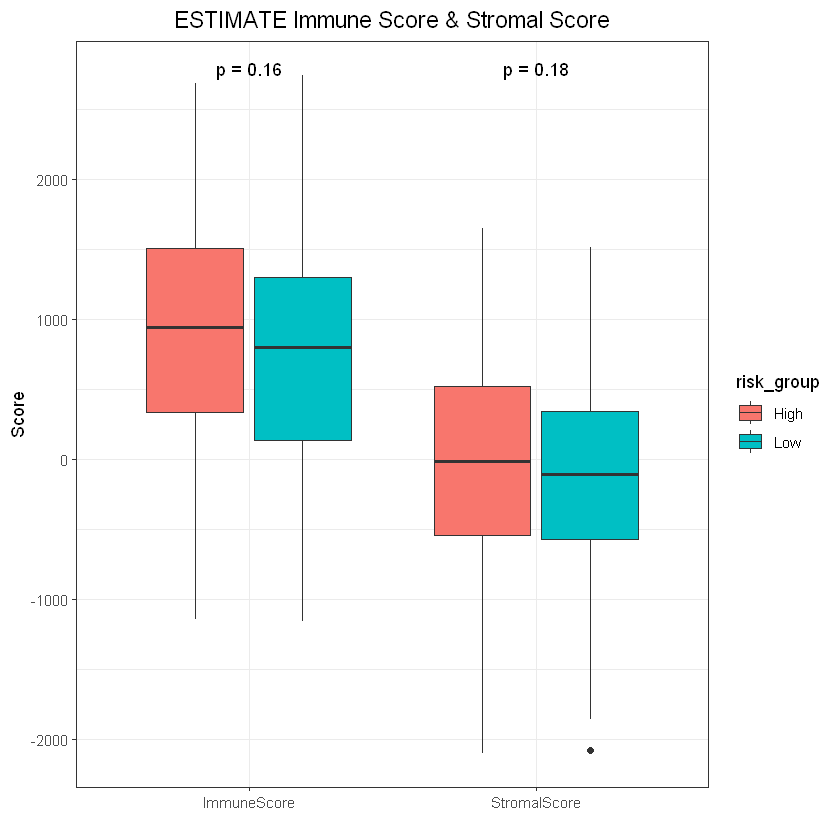

In [13]:
# 高低风险组 ESTIMATE 评分对比
library(ggplot2)
library(ggpubr)
library(reshape)

plot_data <- train_risk_estimate_df[, c("risk_group", "ImmuneScore", "StromalScore")]
plot_data_melt <- melt(plot_data, id.vars = "risk_group")
estimate_p <- ggplot(plot_data_melt, aes(x = variable, y = value, fill = risk_group)) +
    geom_boxplot() + theme_bw() +
    stat_compare_means(method = "wilcox.test", label = "p.format") +
    labs(title = "ESTIMATE Immune Score & Stromal Score", x = "", y = "Score")+
    theme(plot.title = element_text(hjust = 0.5, size = 14))
print(estimate_p)
ggsave(paste0(result_dir, "ESTIMATE/ESTIMATE_Immune_Stromal_Score.boxplot.pdf"), estimate_p, width= 10 , height= 8, dpi=300)

* MCPcounter分析（10种免疫与基质细胞得分）
Estimate包只能对肿瘤的基质成分和免疫成分进行评估，不能对免疫细胞类群进行更为详细的分类。MCPcounter可以利用转录组数据量化8个免疫细胞和2个基质细胞的绝对丰度:T cells、CD8 T cells、Cytotoxic lymphocytes、B lineage、NK cells、Monocytic lineage、Myeloid dendritic cells、Neutrophils、Endothelial cells、Fibroblasts。但是基因集中CD8 T细胞只有一个特征基因CD8B，做出来的结果中也没有CD8 T细胞。

In [50]:
library(MCPcounter)

dir.create(paste0(result_dir, "MCPcounter"), recursive = TRUE)

# 获取probes & genes
#probesets=read.table(curl("http://raw.githubusercontent.com/ebecht/MCPcounter/master/Signatures/probesets.txt"),
#                     sep="\t",stringsAsFactors=FALSE,colClasses="character")

#head(probesets)
#write.csv(probesets, file = paste0(result_dir, "MCPcounter/probeset.txt"))

#genes=read.table(curl("http://raw.githubusercontent.com/ebecht/MCPcounter/master/Signatures/genes.txt"),
#                 sep="\t",stringsAsFactors=FALSE,header=TRUE,colClasses="character",check.names=FALSE)

#head(genes)
#write.csv(genes, file = paste0(result_dir, "MCPcounter/genes.txt"))

# 读取probes & genes
probesets <- read.table(paste0(result_dir, "MCPcounter/probesets.txt"), sep="\t",stringsAsFactors=FALSE,colClasses="character")
genes <- read.table(paste0(result_dir, "MCPcounter/genes.txt"), sep="\t",stringsAsFactors=FALSE,header=TRUE,colClasses="character", check.names=FALSE)                
# MCPcounter分析
res_mcp <- MCPcounter.estimate(rna_final, featuresType="HUGO_symbols",
                              probesets=probesets,
                              genes=genes)

head(res_mcp)

# 合并到训练集风险分组数据
train_mcp <- t(res_mcp)[match(train_risk_df$sample_id, colnames(res_mcp)),]
train_risk_mcp_df <- cbind(train_risk_df, train_mcp)
print(head(train_risk_mcp_df))

write.table(train_risk_mcp_df, paste0(result_dir, "MCPcounter/train_risk_MCPcounter_df.txt"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

Warning message in dir.create(paste0(result_dir, "MCPcounter"), recursive = TRUE):
"'C:\Users\wenfang\Desktop\TCGA-LUAD\result\high_low_risk_analysis\MCPcounter' already exists"


,TCGA-44-4112-01,TCGA-NJ-A4YP-01,TCGA-86-8278-01,TCGA-62-A470-01,TCGA-44-6778-01,TCGA-49-AARQ-01,TCGA-97-A4M1-01,TCGA-55-6975-01,TCGA-99-8033-01,TCGA-78-7149-01,⋯,TCGA-78-7152-01,TCGA-78-7539-01,TCGA-62-A46S-01,TCGA-95-7947-01,TCGA-J2-8192-01,TCGA-78-7145-01,TCGA-50-6593-01,TCGA-69-7973-01,TCGA-86-7713-01,TCGA-55-8302-01
T cells,5.857007,5.956421,6.071271,4.984129,7.840629,5.905993,5.874700,5.294993,6.436200,4.585579,⋯,6.328929,7.041993,5.939257,6.230493,6.506800,4.7644357,5.449493,5.590971,5.011021,5.928857
CD8 T cells,6.147300,6.172700,4.832100,4.812200,7.217600,8.317300,5.947100,5.037900,7.121900,4.750400,⋯,6.216300,7.543600,5.552000,5.949800,5.489400,2.3430000,4.195300,8.149900,4.470100,5.636100
Cytotoxic lymphocytes,5.036871,5.207000,4.764914,3.287500,6.381800,4.632429,4.495686,4.712000,6.108086,4.349500,⋯,4.515271,4.976857,4.318786,4.624943,3.968400,2.7010286,3.046586,3.909271,3.182543,4.243014
B lineage,5.413012,5.259000,6.497475,4.799850,8.578625,5.211425,4.280775,6.114425,5.496462,5.465475,⋯,8.049613,5.936063,5.362850,6.936200,6.817400,4.9034500,5.971600,6.619612,4.495387,6.503375
NK cells,2.080338,2.880600,1.745413,1.238187,3.822925,4.095363,2.287325,1.595738,3.814338,2.007637,⋯,1.470413,2.080138,3.151550,3.043475,1.869263,0.8158625,0.829950,3.108262,2.104563,2.222837
Monocytic lineage,8.329400,8.763357,8.699657,8.496986,10.461843,7.896343,8.387314,8.581729,9.279571,7.101214,⋯,7.985586,8.795971,8.515857,8.192000,9.581271,8.3470000,9.425814,7.818486,8.152929,8.838171


        sample_id OS.time OS  risk_score risk_group  T cells CD8 T cells
1 TCGA-NJ-A4YP-01      50  0  0.02481780       High 5.956421      6.1727
2 TCGA-62-A470-01    1194  1 -0.06045875        Low 4.984129      4.8122
3 TCGA-44-6778-01    1864  0  0.02108808       High 7.840629      7.2176
4 TCGA-97-A4M1-01     601  0 -0.36222464        Low 5.874700      5.9471
5 TCGA-78-7149-01    3940  0 -0.21608553        Low 4.585579      4.7504
6 TCGA-50-6597-01    1268  1 -0.21397559        Low 6.905993      6.6569
  Cytotoxic lymphocytes B lineage NK cells Monocytic lineage
1              5.207000  5.259000 2.880600          8.763357
2              3.287500  4.799850 1.238187          8.496986
3              6.381800  8.578625 3.822925         10.461843
4              4.495686  4.280775 2.287325          8.387314
5              4.349500  5.465475 2.007637          7.101214
6              3.668143  7.314763 1.114950          7.575743
  Myeloid dendritic cells Neutrophils Endothelial cells Fibrob

In [51]:
# 统计
mcp_df <- as.data.frame(t(res_mcp))
mcp_df$sample_id <- rownames(mcp_df)
mcp_df <- merge(mcp_df, train_risk_df[, c("sample_id", "risk_group")], by = "sample_id")

# 对所有细胞类型做统计检验
cell_types <- rownames(res_mcp)
results_list <- list()

for(cell in cell_types) {
    formula <- as.formula(paste0("`", cell, "` ~ risk_group"))
    test <- wilcox.test(formula, data = mcp_df)
    high_mean <- mean(mcp_df[mcp_df$risk_group == "High", cell], na.rm = TRUE)
    low_mean <- mean(mcp_df[mcp_df$risk_group == "Low", cell], na.rm = TRUE)
    
    results_list[[cell]] <- data.frame(
        Cell_Type = cell,
        High_mean = high_mean,
        Low_mean = low_mean,
        P_value = test$p.value,
        Direction = ifelse(high_mean > low_mean, "High > Low", "Low > High")
    )
}

# 汇总结果
results_df <- do.call(rbind, results_list)
results_df$FDR <- p.adjust(results_df$P_value, method = "BH")

# 标星号
results_df$Significance <- ""
results_df$Significance[results_df$P_value < 0.05] <- "*"
results_df$Significance[results_df$P_value < 0.01] <- "**"
results_df$Significance[results_df$P_value < 0.001] <- "***"

print(results_df)
write.table(results_df, paste0(result_dir, "MCPcounter/train_risk_MCPcounter_high_low_risk_signif.txt"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

                                      Cell_Type High_mean  Low_mean
T cells                                 T cells  6.190738  6.063484
CD8 T cells                         CD8 T cells  6.159648  5.618463
Cytotoxic lymphocytes     Cytotoxic lymphocytes  4.765913  4.240064
B lineage                             B lineage  6.313843  6.290237
NK cells                               NK cells  2.414260  2.152067
Monocytic lineage             Monocytic lineage  8.930190  8.557089
Myeloid dendritic cells Myeloid dendritic cells  5.612957  6.501635
Neutrophils                         Neutrophils  6.444966  6.672737
Endothelial cells             Endothelial cells  7.767211  8.164259
Fibroblasts                         Fibroblasts 12.124505 11.640737
                             P_value  Direction          FDR Significance
T cells                 2.100756e-01 High > Low 2.334173e-01             
CD8 T cells             1.584525e-03 High > Low 2.263608e-03           **
Cytotoxic lymphocytes   2.4977

agg_record_178010f31a0c 
                      2

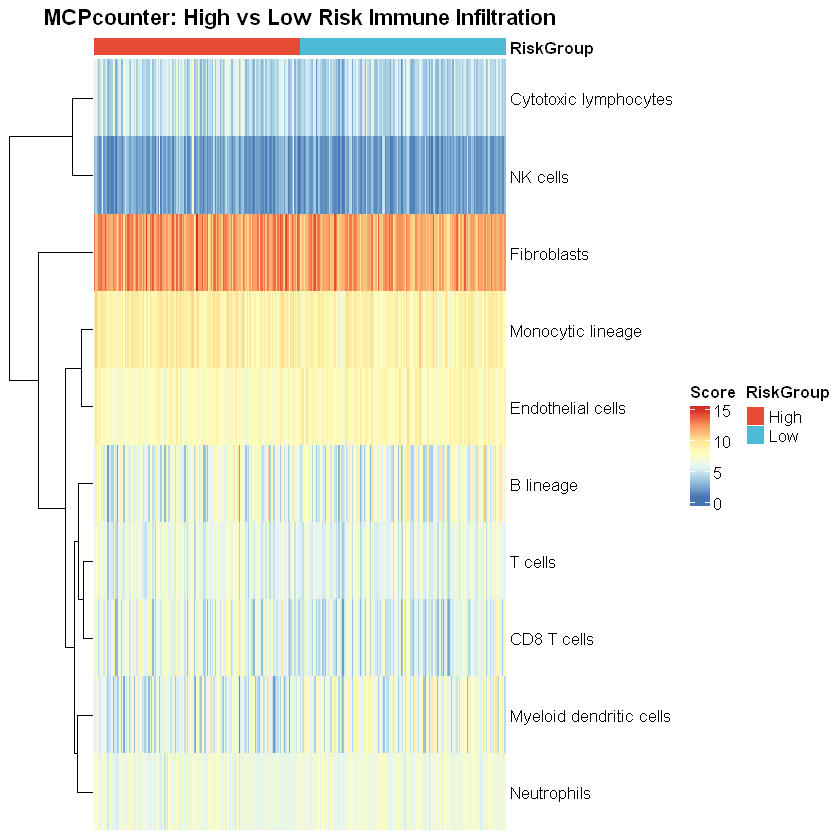

In [57]:
# 热图：高风险 vs 低风险组 10 种细胞得分
library(pheatmap)

# 按风险组排序
heat_order <- order(train_risk_mcp_df$risk_group)
heat_data <- t(t(res_mcp)[train_risk_mcp_df$sample_id[heat_order], ])

# 注释条
anno_colors <- list(
    RiskGroup = c(High = "#E64B35", Low = "#4DBBD5")
)
anno_col <- data.frame(
    RiskGroup = train_risk_mcp_df$risk_group[heat_order],
    row.names = train_risk_mcp_df$sample_id[heat_order]
)

mcp_p <- pheatmap(heat_data, annotation_col = anno_col,
         cluster_rows = TRUE, cluster_cols = FALSE,
         annotation_colors = anno_colors,
         show_colnames = FALSE,
         name = "",
         main = "MCPcounter: High vs Low Risk Immune Infiltration")

print(mcp_p)

pdf(paste0(result_dir, "MCPcounter/MCPcounter.pheatmap.pdf"), width= 10 , height= 8)
print(mcp_p)
dev.off()

* TIMER分析（6种免疫细胞相对比例）

In [59]:
library(immunedeconv)

dir.create(paste0(result_dir, "TIMER"), recursive = TRUE)

n_samples <- ncol(rna_final)
res_timer <- deconvolute(rna_final, "timer", indications = rep("LUAD", n_samples))

# 6 种免疫细胞名字
cell_names <- res_timer$cell_type
print(cell_names)

# 合并到训练集风险分组数据
rownames(res_timer) <- res_timer$cell_type
train_timer <- t(res_timer)[match(train_risk_df$sample_id, colnames(res_timer)),]
train_risk_timer_df <- cbind(train_risk_df, train_timer)
print(head(train_risk_timer_df))

write.table(train_risk_timer_df, paste0(result_dir, "TIMER/train_risk_timer_df.txt"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

Loading required package: EPIC

Warning message in dir.create(paste0(result_dir, "TIMER"), recursive = TRUE):
"'C:\Users\wenfang\Desktop\TCGA-LUAD\result\high_low_risk_analysis\TIMER' already exists"

>>> Running timer

## Enter batch mode



## Loading immune gene expression




[1] "Outlier genes: A2M ACTB ACTG1 ADAM6 AGR2 AKR1B10 AKR1C1 AKR1C2 ALB ALDH1A1 ALDOA AMY1A ANPEP ANXA1 AQP1 AQP3 ASPH B2M C20orf114 C3 CALB1 CALCA CAPZA2 CCT6A CD74 CEACAM5 CEACAM6 CHGB CLU COL1A1 COL1A2 COL3A1 CP CPM CPS1 CST3 CTSB CTSD CUL4A CYP2B7P1 DMBT1 DPCR1 EEF1A1 EEF2 ENO1 EPHX1 ERBB2 FGA FGB FGG FN1 FTH1 FTL FURIN GAPDH GNAS GPX3 H19 HLA-A HLA-B HLA-C HP HSP90AA1 HSP90AB1 HSP90B1 HSPA1A IGF2 IGFBP3 IGFBP5 ITLN1 KRT17 KRT18 KRT19 KRT5 KRT6A KRT8 LAMC2 LAMP1 LCN2 LDHA LDHB LOC96610 LPCAT1 LYZ MMP1 MSLN MSMB MUC5B MUC6 NAPSA NEAT1 NTS ODC1 PABPC1 PCSK1 PGC PI3 PIGR PLS3 PLUNC PRG4 PSAP REG4 RNASE1 RPL3 RPL37 RPL5 RPL8 RPS18 RPS24 RPS6 S100A6 S100A8 S100A9 SCG2 SCGB1A1 SCGB3A1 SCGB3A2 SERPINA1 SFTPA1 SFTPA2 SFTPB SFTPC SLC34A2 SLPI SPARC SPINK1 SPP1 SQSTM1 TF TFDP1 TFF2 TFPI2 TGFBI TIMP1 TMSB10 TMSL3 TPT1 TUBB TXNIP TXNRD1 UBC UGDH VIM YWHAZ"


## Removing the batch effect of C:\Users\wenfang\AppData\Local\Temp\Rtmpuw8Hxy\file17802f5726b8


Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data




[1] "B cell"                 "T cell CD4+"            "T cell CD8+"           
[4] "Neutrophil"             "Macrophage"             "Myeloid dendritic cell"


Warning message:
"Setting row names on a tibble is deprecated."


        sample_id OS.time OS  risk_score risk_group     B cell T cell CD4+
1 TCGA-NJ-A4YP-01      50  0  0.02481780       High 0.06812922  0.14040492
2 TCGA-62-A470-01    1194  1 -0.06045875        Low 0.06331568  0.12912934
3 TCGA-44-6778-01    1864  0  0.02108808       High 0.11093099  0.15893252
4 TCGA-97-A4M1-01     601  0 -0.36222464        Low 0.06553948  0.15101888
5 TCGA-78-7149-01    3940  0 -0.21608553        Low 0.07708195  0.12596558
6 TCGA-50-6597-01    1268  1 -0.21397559        Low 0.10142845  0.16252458
  T cell CD8+ Neutrophil Macrophage Myeloid dendritic cell
1  0.15706722 0.12819503 0.04713189             0.48666816
2  0.12909245 0.11364487 0.07531763             0.46019182
3  0.20438545 0.15175437 0.08152602             0.53277065
4  0.16315098 0.12622572 0.05795366             0.50634253
5  0.16104564 0.10410051 0.03648772             0.46123873
6  0.16081258 0.11073063 0.03347821             0.51969230


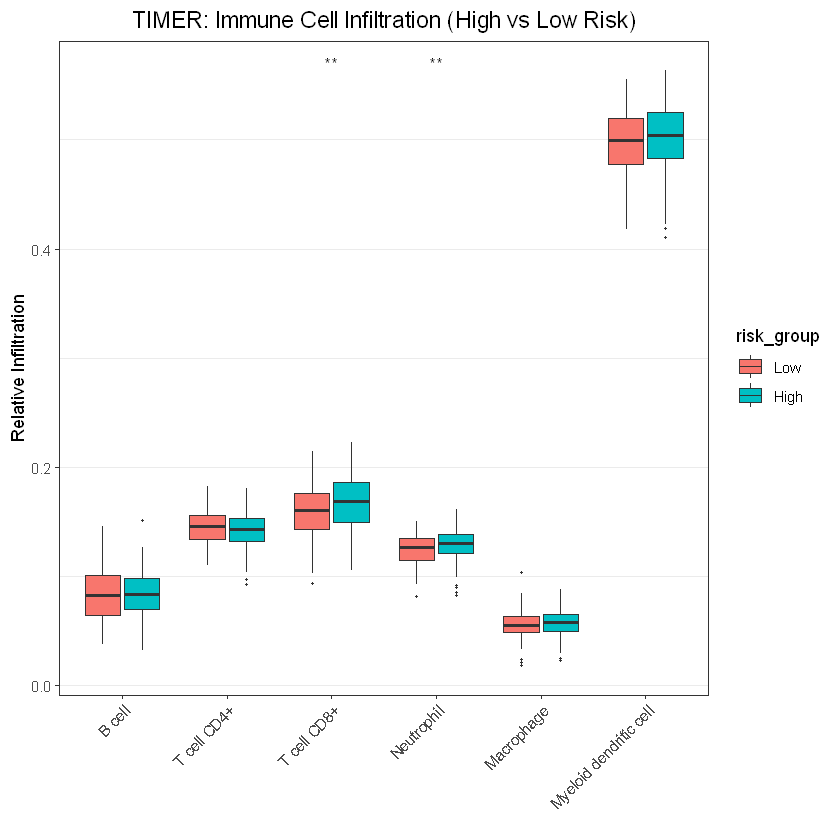

In [62]:
# 6 种免疫细胞在高/低风险组的差异
library(ggpubr)
library(ggplot2)
library(reshape2)

# 将细胞列转换成数值
for (col in res_timer$cell_type) {
  train_risk_timer_df[[col]] <- as.numeric(train_risk_timer_df[[col]])
}
        
train_risk_timer_df$risk_group <- factor(train_risk_timer_df$risk_group, levels = c("Low", "High"))
                
timer_melt <- melt(train_risk_timer_df[, c("risk_group", res_timer$cell_type)],
                   id.vars = "risk_group")

timer_p <- ggplot(timer_melt, aes(x = variable, y = value, fill = risk_group)) +
    geom_boxplot(outlier.size = 0.5) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
         plot.title = element_text(hjust = 0.5, size = 14),
         panel.grid.major.x = element_blank(),
         panel.grid.minor.x = element_blank()) +
    labs(title = "TIMER: Immune Cell Infiltration (High vs Low Risk)",
         x = "", y = "Relative Infiltration") +
    stat_compare_means(aes(group = risk_group), method = "wilcox.test", label = "p.signif",
                       hide.ns = TRUE)

print(timer_p)
ggsave(paste0(result_dir, "TIMER/TIMER.boxplot.pdf"), timer_p, width= 10 , height= 8, dpi=300)

### 药物敏感性预测

In [8]:
library(pRRophetic)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)

# defined drug list
drug_to_predict <- c(
  # 化疗药
  "Cisplatin", "Paclitaxel", "Gemcitabine", "Docetaxel", "Methotrexate",
  # 靶向药
  "Erlotinib", "Imatinib", "Rapamycin",
  # PARP抑制剂  Rucaparib(AG-014699)
  "AG-014699", "Talazoparib", 
  # CDK抑制剂
  "RO-3306", "Roscovitine"
)

# result
predicted_ic50 <- matrix(NA, nrow = length(drug_to_predict), ncol = ncol(rna_final),
                        dimnames = list(drug_to_predict, colnames(rna_final)))

# predict
for (drug in drug_to_predict) {
  cat("正在预测药物:", drug, "\n")
  tryCatch({
    predicted_ic50[drug, ] <- pRRopheticPredict(
      testMatrix = rna_final,
      drug = drug,
      tissueType = "lung", 
      batchCorrect = "eb", # 使用 Combat 进行批次校正
      dataset = "cgp2016"
    )
  }, error = function(e) {
    cat("药物", drug, "预测失败:", e$message, "\n")
  })
}

正在预测药物: Cisplatin 

Using updated CGP 2016 datsets for prediction


 15177  gene identifiers overlap between the supplied expression matrices... 
 

Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data





 3036 low variabilty genes filtered.
Fitting Ridge Regression model... Done

Calculating predicted phenotype...Done

正在预测药物: Paclitaxel 

Using updated CGP 2016 datsets for prediction


 15177  gene identifiers overlap between the supplied expression matrices... 
 

Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data





 3036 low variabilty genes filtered.
Fitting Ridge Regression model... Done

Calculating predicted phenotype...Done

正在预测药物: Gemcitabine 

Using updated CGP 2016 datsets for prediction


 15177  gene identifiers overlap between the supplied expression matrices... 
 

...


 3036 low variabilty genes filtered.
Fitting Ridge Regression model... Done

Calculating predicted phenotype...Done

正在预测药物: RO-3306 

Using updated CGP 2016 datsets for prediction


 15177  gene identifiers overlap between the supplied expression matrices... 
 

Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data





 3036 low variabilty genes filtered.
Fitting Ridge Regression model... Done

Calculating predicted phenotype...Done

正在预测药物: Roscovitine 

Using updated CGP 2016 datsets for prediction


 15177  gene identifiers overlap between the supplied expression matrices... 
 

Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data





 3036 low variabilty genes filtered.
Fitting Ridge Regression model... Done

Calculating predicted phenotype...Done



In [26]:
# 合并风险分组信息
drug_long <- as.data.frame(t(predicted_ic50)) %>%
  tibble::rownames_to_column("sample_id") %>%
  pivot_longer(cols = -sample_id, names_to = "Drug", values_to = "IC50") %>%
  inner_join(train_risk_df, by = "sample_id") 

head(drug_long)
write.table(drug_long, paste0(result_dir, "Drug_sensitivity/pRRophetic.drugs.IC50.txt"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

sample_id,Drug,IC50,OS.time,OS,risk_score,risk_group
<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<chr>
TCGA-NJ-A4YP-01,Cisplatin,3.1932384,50,0,0.0248178,High
TCGA-NJ-A4YP-01,Paclitaxel,-2.5870414,50,0,0.0248178,High
TCGA-NJ-A4YP-01,Gemcitabine,-2.8772759,50,0,0.0248178,High
TCGA-NJ-A4YP-01,Docetaxel,-5.0533991,50,0,0.0248178,High
TCGA-NJ-A4YP-01,Methotrexate,-0.5743773,50,0,0.0248178,High
TCGA-NJ-A4YP-01,Erlotinib,2.5878340,50,0,0.0248178,High


In [29]:
# 秩和检验
add_signif <- function(p) {
    if(is.na(p)) return("")
    if(p<0.001) return("***")
    else if(p<0.01) return("**")
    else if (p<0.05) return("*")
    else return("")
}

drugs <- unique(drug_long$Drug)
p_results <- data.frame(drug = character(), p_value = numeric())

for (dg in drugs) {
  sub <- drug_long[drug_long$Drug == dg, ]
  test <- wilcox.test(IC50 ~ risk_group, data = sub)
  p_results <- rbind(p_results, data.frame(drug = dg, p_value = test$p.value))
}
p_results$signif <- sapply(p_results$p_value, add_signif)
write.table(p_results, paste0(result_dir, "Drug_sensitivity/pRRophetic.drugs.signif.txt"), sep="\t", row.names = FALSE, col.names=TRUE)

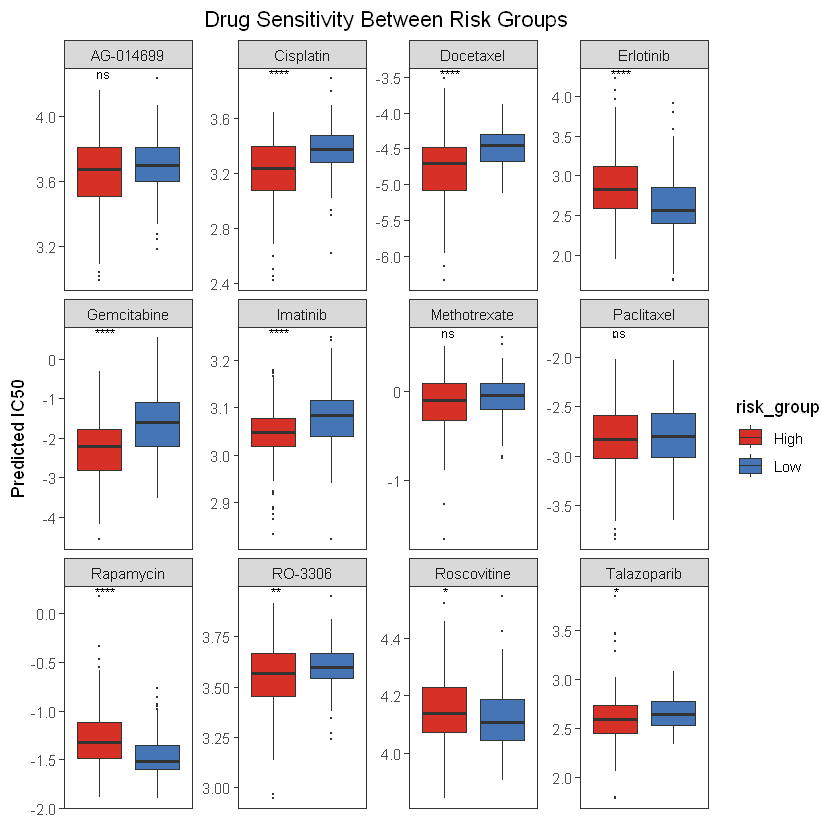

In [33]:
# 箱线图
p_drug_boxplot <- ggplot(drug_long, aes(x = risk_group, y = IC50, fill = risk_group)) +
  geom_boxplot(outlier.size = 0.3) +
  facet_wrap(~ Drug, scales = "free_y", ncol = 4) + 
  stat_compare_means(method = "wilcox.test", label = "p.signif", size = 2.5) +
  scale_fill_manual(values = c("High" = "#D73027", "Low" = "#4575B4")) +
  theme_bw() +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(),
       panel.grid.major = element_blank(),
       panel.grid.minor = element_blank(),
       panel.background = element_blank(),
       plot.title = element_text(hjust=0.5)
       ) +
  labs(x = "", y = "Predicted IC50", title = "Drug Sensitivity Between Risk Groups")

# 显示图片
print(p_drug_boxplot)

ggsave(paste0(result_dir, "Drug_sensitivity/Drug_sensitivity.pRRophetic.pdf"), p_drug_boxplot, width= 10 , height= 8, dpi=300)